In [74]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [75]:
### loading packages
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt

In [76]:
data = np.loadtxt('./drive/MyDrive/sindata_1000.csv', delimiter=',')
data.shape

(1000,)

In [77]:
split = int(0.8 * len(data))
print(f'数据大小为 {len(data)}')

数据大小为 1000


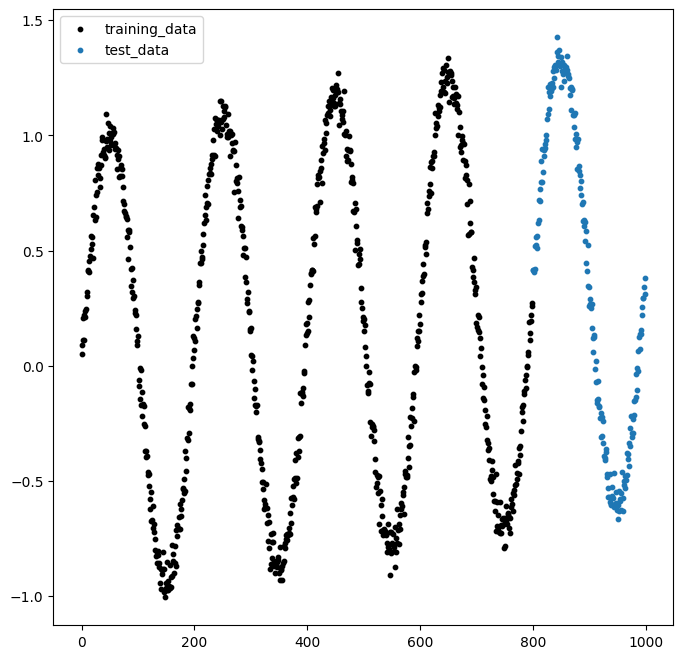

In [78]:
plt.figure(figsize=(8,8))
plt.scatter(np.arange(split), data[:split], c = 'black', s = 10, label = 'training_data')
plt.scatter(np.arange(split, len(data)), data[split:], c = None, s = 10, label = 'test_data')
plt.legend()
plt.show()

In [79]:
train_data = data[:split]
test_data = data[split:]

In [80]:
seq_len = 20
train_num = len(train_data) // (seq_len + 1) * (seq_len + 1)
train_data = train_data[:train_num].reshape(-1, seq_len + 1, 1)
np.random.seed(0)
torch.manual_seed(0)

x_train = torch.from_numpy(train_data[:,:seq_len,:]).float()
y_train = torch.from_numpy(train_data[:,1:seq_len+1,:]).float()

x_test = torch.from_numpy(test_data[:-1]).float()
y_test = torch.from_numpy(test_data[1:]).float()

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

torch.Size([38, 20, 1])
torch.Size([38, 20, 1])
torch.Size([199])
torch.Size([199])


In [81]:
class LSTM(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super().__init__()
    self.lstm = nn.LSTM(input_size = input_size, hidden_size = hidden_size, batch_first=True, num_layers= 1)
    ### 输入格式是(batch_size, seq_len, input_size)
    self.linear = nn.Linear(hidden_size, output_size)
    self.hidden_size = hidden_size

  def forward(self, x, hidden): ### x 的维度是(batch_size, seq_len, input_size)
    out, hidden = self.lstm(x, hidden) ## hidden 的维度是(1, batch_size, hidden_size) out的维度是(batch_size, seq_len, hidden_size)
    out = self.linear(out.reshape(-1, self.hidden_size))
    return out, hidden

  def init_hidden(self, batch_size):
    return (torch.zeros(1, batch_size, self.hidden_size).float().to('cuda'),
            torch.zeros(1, batch_size, self.hidden_size).float().to('cuda'))


In [82]:
input_size = 1
output_size = 1
hidden_size = 16

lstm = LSTM(input_size, hidden_size, output_size)
criterion = nn.MSELoss()
lstm_optimizer = torch.optim.Adam(lstm.parameters(), lr = 0.001)

def test_lstm(lstm, x, hidden, pred_steps):
  pred = []
  inp = x.view(-1, input_size)
  for i in range(pred_steps):
    out, hidden = lstm(inp.unsqueeze(0), hidden)
    pred.append(out.detach())
    inp = out
    # print(pred)
  return torch.cat(pred, dim=0).view(-1)

In [83]:
hidden_1 = 32
hidden_2 = 16
mlp = nn.Sequential(
    nn.Linear(input_size, hidden_1),
    nn.ReLU(),
    nn.Linear(hidden_1, hidden_2),
    nn.ReLU(),
    nn.Linear(hidden_2, output_size)
)
mlp_optimizer = torch.optim.Adam(mlp.parameters(), lr = 0.001)
# sum([p.numel() for p in mlp.parameters()])

In [84]:
def test_mlp(mlp, x, pred_steps):
  pred = []
  # print(x)
  inp = x.view(-1, input_size)
  # print(inp.shape)
  for i in range(pred_steps):
    out = mlp(inp)
    pred.append(out.detach())
    inp = out
  return torch.cat(pred, dim=0).view(-1)
# test_mlp(mlp.to('cuda'), x_test[:5].to('cuda'), 10)

In [85]:
x_test[0].to('cuda')

tensor(0.4160, device='cuda:0')

In [86]:
lstm

LSTM(
  (lstm): LSTM(1, 16, batch_first=True)
  (linear): Linear(in_features=16, out_features=1, bias=True)
)

In [87]:
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

max_epoch = 1000
criterion = nn.MSELoss()

lstm.to(device)
mlp.to(device)

lstm_losses = []
mlp_losses = []
lstm_test_losses = []
mlp_test_losses = []

best_lstm_test_loss = float('inf')
best_mlp_test_loss = float('inf')

with tqdm(range(max_epoch)) as pbar:
  for epoch in pbar:
    lstm_loss_sum = 0.0
    mlp_loss_sum = 0.0

    for X, y in zip(x_train, y_train):
      # Move X and y to the correct device
      X = X.to(device)
      y = y.to(device)

      # Initialize hidden state for each new sequence
      hidden = lstm.init_hidden(X.unsqueeze(0).size(0))

      # LSTM training step
      lstm_pred, hidden = lstm(X.unsqueeze(0), hidden)
      lstm_loss = criterion(lstm_pred.view(y.shape), y)
      lstm_optimizer.zero_grad()
      lstm_loss.backward()
      torch.nn.utils.clip_grad_norm_(lstm.parameters(), max_norm=5)  # 裁剪到范数 5
      lstm_optimizer.step()
      lstm_loss_sum += lstm_loss.item()

      # MLP training step
      mlp_pred = mlp(X)
      mlp_loss = criterion(mlp_pred, y)
      mlp_optimizer.zero_grad()
      mlp_loss.backward()
      mlp_optimizer.step()
      mlp_loss_sum += mlp_loss.item()

    lstm_loss_avg = lstm_loss_sum / len(x_train)
    mlp_loss_avg = mlp_loss_sum / len(x_train)
    lstm_losses.append(lstm_loss_avg)
    mlp_losses.append(mlp_loss_avg)

    # Test evaluation
    with torch.no_grad():
      lstm.eval()
      mlp.eval()

      # Move x_test[0] and y_test to the correct device for testing
      x_test_device = x_test[0].to(device)
      y_test_device = y_test.to(device)

      # Re-initialize hidden state for test prediction, ensuring it's on the correct device
      test_hidden = lstm.init_hidden(1)

      lstm_pred_test = test_lstm(lstm, x_test_device, test_hidden, len(y_test_device))
      mlp_pred_test = test_mlp(mlp, x_test_device, len(y_test_device))

      lstm_test_loss = criterion(lstm_pred_test, y_test_device)
      mlp_test_loss = criterion(mlp_pred_test, y_test_device)

      lstm_test_losses.append(lstm_test_loss.item())
      mlp_test_losses.append(mlp_test_loss.item())

      # Save best models
      if lstm_test_loss.item() < best_lstm_test_loss:
        best_lstm_test_loss = lstm_test_loss.item()
        torch.save(lstm.state_dict(), 'best_lstm_model.pth')

      if mlp_test_loss.item() < best_mlp_test_loss:
        best_mlp_test_loss = mlp_test_loss.item()
        torch.save(mlp.state_dict(), 'best_mlp_model.pth')

      lstm.train()
      mlp.train()

    pbar.set_postfix({
        'Epoch': epoch,
        'lstm loss': lstm_loss_avg,
        'MLP loss': mlp_loss_avg,
        'lstm test loss': lstm_test_loss.item(),
        'MLP test loss': mlp_test_loss.item()
    })

100%|██████████| 1000/1000 [03:29<00:00,  4.78it/s, Epoch=999, lstm loss=0.00361, MLP loss=0.00561, lstm test loss=1.14, MLP test loss=0.594]


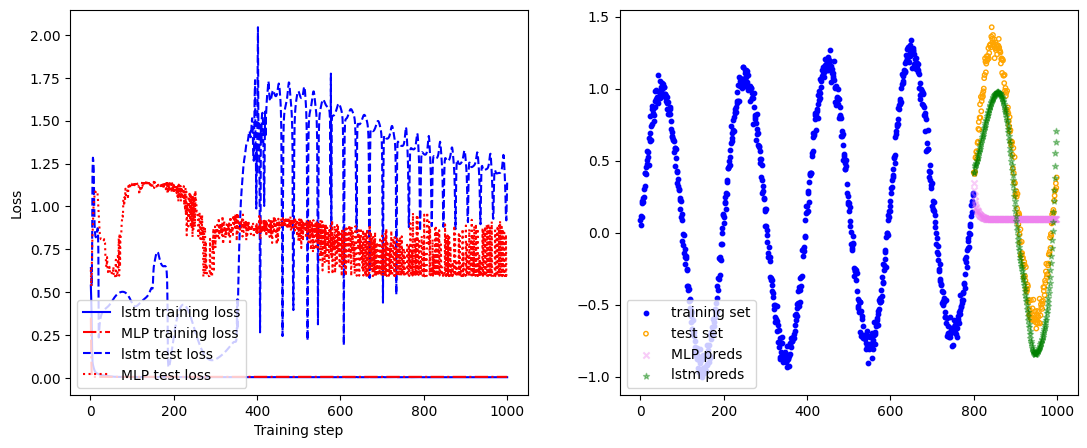

In [90]:
lstm.load_state_dict(torch.load('best_lstm_model.pth'))
mlp.load_state_dict(torch.load('best_mlp_model.pth'))

lstm.eval()
mlp.eval()

with torch.no_grad():
  eval_hidden = lstm.init_hidden(1)
  lstm_preds = test_lstm(lstm, x_test[0].to(device), eval_hidden, len(y_test)).cpu().numpy()
  mlp_preds = test_mlp(mlp, x_test[0].to(device), len(y_test)).cpu().numpy()

num_data = len(data)
plt.figure(figsize=(13, 5))

# 绘制训练曲线
plt.subplot(121)
x_plot = np.arange(len(lstm_losses)) + 1
plt.plot(x_plot, lstm_losses, color='blue',
    label='lstm training loss')
plt.plot(x_plot, mlp_losses, color='red',
    ls='-.', label='MLP training loss')
plt.plot(x_plot, lstm_test_losses, color='blue',
    ls='--', label='lstm test loss')
plt.plot(x_plot, mlp_test_losses, color='red',
    ls=':', label='MLP test loss')
plt.xlabel('Training step')
plt.ylabel('Loss')
plt.legend(loc='lower left')

# 绘制真实数据与模型预测值的图像
plt.subplot(122)
plt.scatter(np.arange(split), data[:split], color='blue',
    s=10, label='training set')
plt.scatter(np.arange(split, num_data), data[split:], color='none',
    edgecolor='orange', s=10, label='test set')
plt.scatter(np.arange(split, num_data - 1), mlp_preds, color='violet',
    marker='x', alpha=0.4, s=20, label='MLP preds')
plt.scatter(np.arange(split, num_data - 1), lstm_preds, color='green',
    marker='*', alpha=0.4, s=20, label='lstm preds')
plt.legend(loc='lower left')
plt.savefig('output_20_0.png')
plt.savefig('output_20_0.pdf')
plt.show()